# Disease Prediction System

This notebook aims to develop a Disease Prediction System.

**Key Features:**
* Predict disease from symptoms
* Healthcare dashboard
* Accuracy comparison

**Algorithms to be explored:**
* Random Forest
* Decision Tree

## 1. Setup and Data Loading

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


### Load Dataset

To predict diseases from symptoms, we need a dataset containing symptoms as features and diseases as target labels.

Please provide the path to your dataset. If you don't have one, I can generate a small synthetic dataset for demonstration. Let me know how you'd like to proceed!

In [ ]:
# Generate a synthetic dataset for demonstration

# Define possible symptoms and diseases
symptoms = [
    'fever', 'cough', 'fatigue', 'sore_throat', 'headache',
    'nausea', 'vomiting', 'diarrhea', 'rash', 'muscle_pain',
    'chest_pain', 'shortness_of_breath', 'dizziness', 'loss_of_smell_taste'
]
diseases = ['Common Cold', 'Flu', 'Food Poisoning', 'Allergy', 'COVID-19']

# Create a function to generate a random set of symptoms for a given disease
def generate_symptoms(disease):
    if disease == 'Common Cold':
        return np.random.choice(['fever', 'cough', 'fatigue', 'sore_throat', 'headache'], size=np.random.randint(2, 4), replace=False).tolist()
    elif disease == 'Flu':
        return np.random.choice(['fever', 'cough', 'fatigue', 'sore_throat', 'headache', 'muscle_pain'], size=np.random.randint(3, 5), replace=False).tolist()
    elif disease == 'Food Poisoning':
        return np.random.choice(['nausea', 'vomiting', 'diarrhea', 'fatigue', 'headache'], size=np.random.randint(2, 4), replace=False).tolist()
    elif disease == 'Allergy':
        return np.random.choice(['cough', 'sore_throat', 'rash', 'fatigue', 'headache'], size=np.random.randint(2, 4), replace=False).tolist()
    elif disease == 'COVID-19':
        return np.random.choice(['fever', 'cough', 'fatigue', 'shortness_of_breath', 'loss_of_smell_taste', 'headache', 'muscle_pain'], size=np.random.randint(3, 6), replace=False).tolist()
    return []

# Generate 1000 samples
data = []
num_samples = 1000
for _ in range(num_samples):
    disease = np.random.choice(diseases)
    symptom_list = generate_symptoms(disease)
    row = {s: 0 for s in symptoms} # Initialize all symptoms to 0
    for s in symptom_list:
        row[s] = 1 # Mark present symptoms as 1
    row['prognosis'] = disease
    data.append(row)

df = pd.DataFrame(data)

print("Synthetic dataset generated successfully with shape:", df.shape)
print("First 5 rows of the dataset:")
print(df.head())

Synthetic dataset generated successfully with shape: (1000, 15)
First 5 rows of the dataset:
   fever  cough  fatigue  sore_throat  headache  nausea  vomiting  diarrhea  \
0      0      0        1            1         1       0         0         0   
1      1      0        0            0         1       0         0         0   
2      0      0        0            0         0       1         1         0   
3      0      1        0            1         1       0         0         0   
4      0      0        0            0         1       1         0         0   

   rash  muscle_pain  chest_pain  shortness_of_breath  dizziness  \
0     0            0           0                    0          0   
1     0            1           0                    1          0   
2     0            0           0                    0          0   
3     0            0           0                    0          0   
4     0            0           0                    0          0   

   loss_of_smell_taste 

## 2. Data Preprocessing

In [ ]:
# Separate features (symptoms) and target (prognosis)
X = df.drop('prognosis', axis=1)
y = df['prognosis']

# Encode target labels into numerical format
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print("Data preprocessing complete!")
print(f"Shape of training features (X_train): {X_train.shape}")
print(f"Shape of testing features (X_test): {X_test.shape}")
print(f"Shape of training target (y_train): {y_train.shape}")
print(f"Shape of testing target (y_test): {y_test.shape}")

# Display the mapping of encoded labels to original disease names
print("\nDisease mapping:")
for i, disease in enumerate(label_encoder.classes_):
    print(f"{i}: {disease}")

Data preprocessing complete!
Shape of training features (X_train): (800, 14)
Shape of testing features (X_test): (200, 14)
Shape of training target (y_train): (800,)
Shape of testing target (y_test): (200,)

Disease mapping:
0: Allergy
1: COVID-19
2: Common Cold
3: Flu
4: Food Poisoning


## 3. Model Training and Evaluation

### 3.1 Random Forest Classifier

Random Forest Classifier Accuracy: 0.7750

Random Forest Classification Report:
                 precision    recall  f1-score   support

       Allergy       0.65      0.82      0.73        45
      COVID-19       0.97      0.87      0.92        39
   Common Cold       0.64      0.52      0.57        44
           Flu       0.77      0.65      0.70        31
Food Poisoning       0.89      1.00      0.94        41

      accuracy                           0.78       200
     macro avg       0.78      0.77      0.77       200
  weighted avg       0.78      0.78      0.77       200


Random Forest Confusion Matrix:
 [[37  0  7  0  1]
 [ 0 34  1  4  0]
 [15  0 23  2  4]
 [ 5  1  5 20  0]
 [ 0  0  0  0 41]]


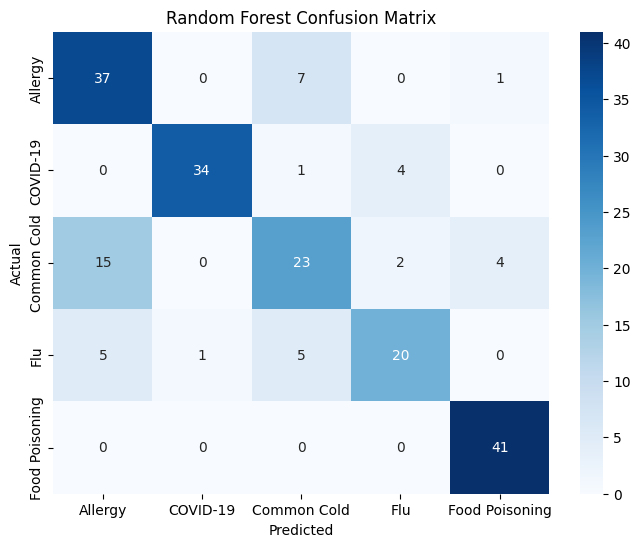

In [ ]:
# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_classifier.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Random Forest Classifier Accuracy: {accuracy_rf:.4f}")
print("\nRandom Forest Classification Report:\n", report_rf)
print("\nRandom Forest Confusion Matrix:\n", conf_matrix_rf)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 3.2 Decision Tree Classifier

Decision Tree Classifier Accuracy: 0.7750

Decision Tree Classification Report:
                 precision    recall  f1-score   support

       Allergy       0.65      0.82      0.73        45
      COVID-19       0.97      0.87      0.92        39
   Common Cold       0.64      0.52      0.57        44
           Flu       0.77      0.65      0.70        31
Food Poisoning       0.89      1.00      0.94        41

      accuracy                           0.78       200
     macro avg       0.78      0.77      0.77       200
  weighted avg       0.78      0.78      0.77       200


Decision Tree Confusion Matrix:
 [[37  0  7  0  1]
 [ 0 34  1  4  0]
 [15  0 23  2  4]
 [ 5  1  5 20  0]
 [ 0  0  0  0 41]]


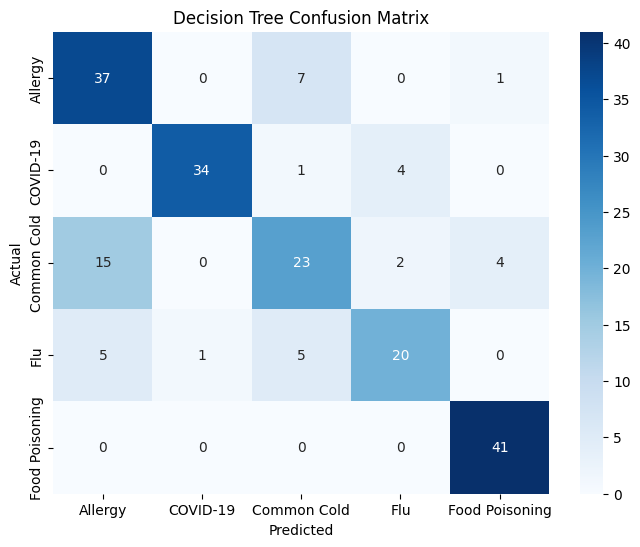

In [ ]:
# Initialize and train the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_classifier.predict(X_test)

# Evaluate the model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
report_dt = classification_report(y_test, y_pred_dt, target_names=label_encoder.classes_)
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)

print(f"Decision Tree Classifier Accuracy: {accuracy_dt:.4f}")
print("\nDecision Tree Classification Report:\n", report_dt)
print("\nDecision Tree Confusion Matrix:\n", conf_matrix_dt)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 5.1 Disease Prediction System

In [ ]:
def predict_disease(input_symptoms, model, symptom_columns, label_encoder):
    """
    Predicts disease based on a list of input symptoms.

    Args:
        input_symptoms (list): A list of strings, each representing a symptom.
        model: The trained machine learning model (e.g., RandomForestClassifier).
        symptom_columns (list): A list of all possible symptom columns in the same order as used for training.
        label_encoder: The LabelEncoder fitted on the disease labels.

    Returns:
        str: The predicted disease.
    """
    # Create an input vector with all symptoms initialized to 0
    input_vector = pd.DataFrame(0, index=[0], columns=symptom_columns)

    # Mark the presence of input symptoms as 1
    for symptom in input_symptoms:
        if symptom in symptom_columns:
            input_vector[symptom] = 1
        else:
            print(f"Warning: Symptom '{symptom}' not recognized.")

    # Predict the encoded label
    predicted_encoded_label = model.predict(input_vector)[0]

    # Decode the label back to the disease name
    predicted_disease = label_encoder.inverse_transform([predicted_encoded_label])[0]

    return predicted_disease

print("Disease prediction function defined.")

Disease prediction function defined.


#### Demo: Predict Disease from Symptoms

In [ ]:
# Example usage of the prediction function
user_symptoms = ['fever', 'cough', 'fatigue', 'sore_throat'] # Example symptoms

# Get the list of symptom columns from our training data X
symptom_columns = X.columns.tolist()

predicted_disease = predict_disease(user_symptoms, rf_classifier, symptom_columns, label_encoder)

print(f"Based on the symptoms {user_symptoms}, the predicted disease is: {predicted_disease}")

user_symptoms_2 = ['nausea', 'vomiting', 'diarrhea']
predicted_disease_2 = predict_disease(user_symptoms_2, rf_classifier, symptom_columns, label_encoder)
print(f"\nBased on the symptoms {user_symptoms_2}, the predicted disease is: {predicted_disease_2}")

Based on the symptoms ['fever', 'cough', 'fatigue', 'sore_throat'], the predicted disease is: Flu

Based on the symptoms ['nausea', 'vomiting', 'diarrhea'], the predicted disease is: Food Poisoning


### 5.2 Healthcare Dashboard

Let's visualize some key aspects of our synthetic healthcare data.

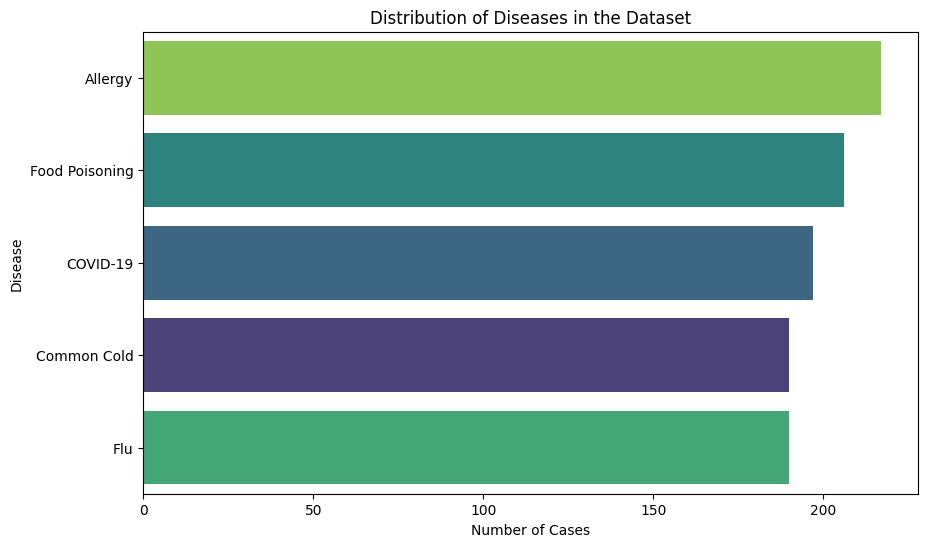

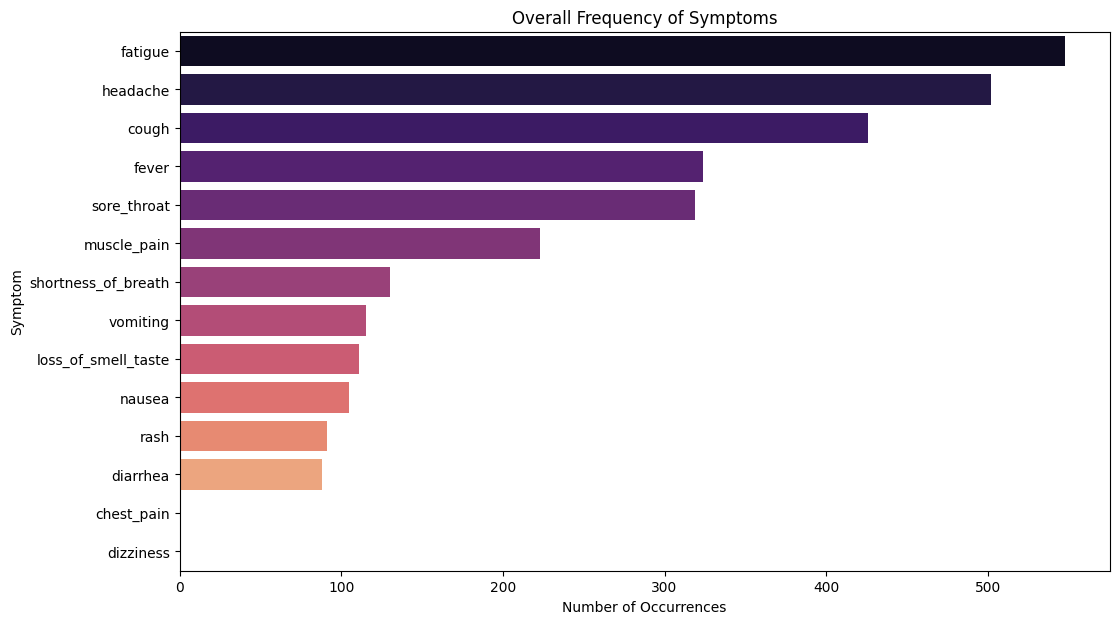

Healthcare dashboard visualizations generated.


In [ ]:
# 1. Distribution of Diseases
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='prognosis', hue='prognosis', legend=False, order=df['prognosis'].value_counts().index, palette='viridis')
plt.title('Distribution of Diseases in the Dataset')
plt.xlabel('Number of Cases')
plt.ylabel('Disease')
plt.show()

# 2. Top Symptoms (Overall)
symptom_counts = X.sum().sort_values(ascending=False)
plt.figure(figsize=(12, 7))
sns.barplot(x=symptom_counts.values, y=symptom_counts.index, hue=symptom_counts.index, legend=False, palette='magma')
plt.title('Overall Frequency of Symptoms')
plt.xlabel('Number of Occurrences')
plt.ylabel('Symptom')
plt.show()

# 3. Symptom correlation (Optional - for more advanced dashboards)
# plt.figure(figsize=(15, 10))
# sns.heatmap(X.corr(), annot=False, cmap='coolwarm')
# plt.title('Symptom Correlation Matrix')
# plt.show()

print("Healthcare dashboard visualizations generated.")